# 01 - Data check

Predict severity 1-6 for triage: close (1-3) or investigate (4-6).

This notebook looks at the data before modelling: schema, dirty values, target mix, useful fields, leakage, and train vs holdback.

Cleaning uses the same `severity_triage` package as the CLI.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from severity_triage import contracts
from severity_triage.config import load_settings
from severity_triage.io import load_datasets
from severity_triage.validation import audit_schema, clean, missingness_table
from severity_triage.features import engineer_features, split_features_target

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

settings = load_settings()
raw = load_datasets(settings)          # verifies the SHA-256 of the workbook first
train_raw, holdback_raw, dictionary = raw.training, raw.holdback, raw.dictionary
TARGET, ID = settings.data.target, settings.data.id_column
print(f"training {train_raw.shape} | holdback {holdback_raw.shape} | dictionary rows {len(dictionary)}")

training (2000, 46) | holdback (500, 45) | dictionary rows 44


## 1. Schema vs data dictionary

Check columns match the dictionary. Catch extra columns, missing columns, and anything that restates the target.


In [2]:
audit_train = audit_schema(train_raw, expect_target=True)
audit_hold = audit_schema(holdback_raw, expect_target=False)
print("TRAINING\n" + audit_train.summary())
print("\nHOLDBACK\n" + audit_hold.summary())

only_in_data = sorted(set(train_raw.columns) - set(dictionary["Field Name"]))
print("\nColumns in the data but not in the dictionary:", only_in_data)
print("Holdback lacks the target column:", TARGET not in holdback_raw.columns)
print("Holdback null rate for OmbudsmanInvestigationRequired:",
      holdback_raw["OmbudsmanInvestigationRequired"].isna().mean())

TRAINING
target present: True
leak columns present: ['OmbudsmanInvestigationRequired']
undocumented columns present: ['AdditionalTreatmentRequired', 'ImpactOnRelationships']
expected but missing: none
unexpected: none

HOLDBACK
target present: False
leak columns present: ['OmbudsmanInvestigationRequired']
undocumented columns present: ['AdditionalTreatmentRequired', 'ImpactOnRelationships']
expected but missing: none
unexpected: none

Columns in the data but not in the dictionary: ['AdditionalTreatmentRequired', 'ImpactOnRelationships']
Holdback lacks the target column: True
Holdback null rate for OmbudsmanInvestigationRequired: 1.0


Two Yes/No columns are in the data but not in the dictionary: `AdditionalTreatmentRequired` and `ImpactOnRelationships`. Kept as features (noted in the README).

`OmbudsmanInvestigationRequired` is filled in training and empty in holdback. Section 9 shows it is a perfect copy of the triage outcome, so it is dropped.


## 2. Target distribution

Check class balance and the base rate for investigate (severity >= 4). Accuracy alone is not useful here.


,count,share_%
SeverityScore,,
1,504.0,25.20
2,491.0,24.55
3,404.0,20.20
4,297.0,14.85
5,203.0,10.15
6,101.0,5.05
progressed (>=4),601.0,30.05


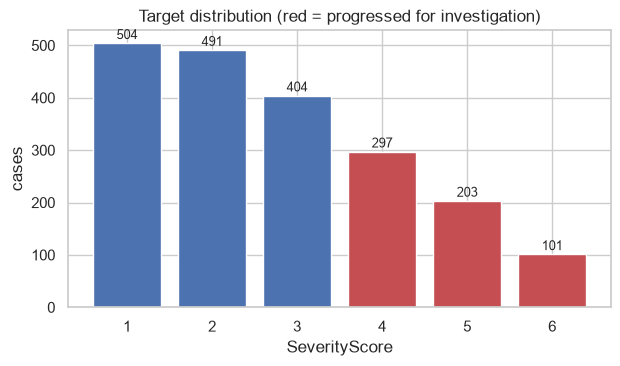

In [3]:
counts = train_raw[TARGET].value_counts().sort_index()
share = (counts / counts.sum() * 100).round(2)
summary = pd.DataFrame({"count": counts, "share_%": share})
summary.loc["progressed (>=4)"] = [counts[counts.index >= 4].sum(), share[share.index >= 4].sum().round(2)]
display(summary)

fig, ax = plt.subplots(figsize=(7, 3.6))
colors = ["#4c72b0" if c < 4 else "#c44e52" for c in counts.index]
ax.bar(counts.index.astype(str), counts.values, color=colors)
ax.set_xlabel("SeverityScore"); ax.set_ylabel("cases")
ax.set_title("Target distribution (red = progressed for investigation)")
for i, v in enumerate(counts.values):
    ax.text(i, v + 8, str(v), ha="center", fontsize=9)
plt.show()

Severity goes from about 25% (level 1) down to 5% (level 6). About 30% of cases are severity 4-6.

An "always close" rule would be ~70% accurate and still miss every severe case. That is why we do not lead with accuracy.


## 3. Missing values

See how much is missing and whether missingness links to severity. That decides how we impute.


,missing,missing_pct,dtype,missing_pct_holdback
FailureTypeSecondary,172,8.60,str,7.2
PrimaryVulnerability,127,6.35,str,6.4
Jurisdiction,112,5.60,str,6.8
EvidenceStrength,58,2.90,str,3.2
ExpectedFinancialRedressGBP,56,2.80,float64,2.4
RecoveryTimeMonths,54,2.70,float64,2.8
PhysicalImpactLevel,47,2.35,str,2.2
OrganisationType,38,1.90,str,1.4
AdditionalCostsGBP,36,1.80,float64,1.6
EmotionalImpactLevel,36,1.80,str,2.8


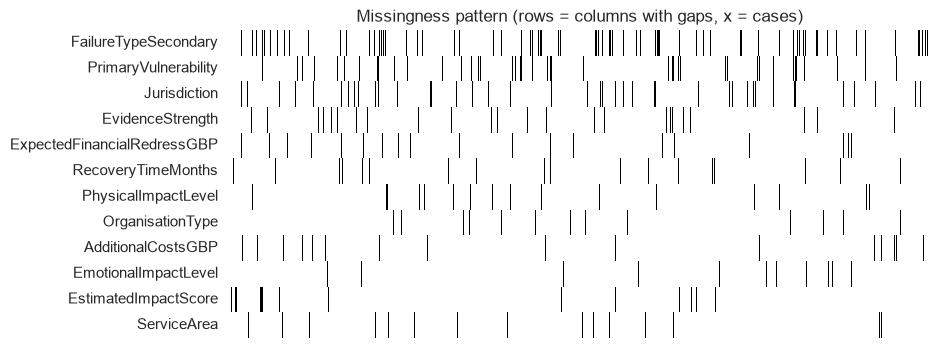

In [4]:
miss = missingness_table(train_raw)
miss_h = missingness_table(holdback_raw).rename(columns={"missing": "missing_holdback", "missing_pct": "missing_pct_holdback"})
display(miss.join(miss_h[["missing_pct_holdback"]], how="left"))

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(train_raw[miss.index].isna().T, cbar=False, cmap="Greys", ax=ax)
ax.set_title("Missingness pattern (rows = columns with gaps, x = cases)"); ax.set_xticks([])
plt.show()

In [5]:
# Is missingness related to the target?  Chi-square of (is-missing) against severity for each column.
rows = []
for col in miss.index:
    if col == "OmbudsmanInvestigationRequired":
        continue
    ct = pd.crosstab(train_raw[col].isna(), train_raw[TARGET])
    chi2, p, _, _ = stats.chi2_contingency(ct)
    rows.append({"column": col, "missing_pct": miss.loc[col, "missing_pct"], "chi2": round(chi2, 2), "p_value": round(p, 3)})
mcar = pd.DataFrame(rows).sort_values("p_value")
display(mcar)
print("Columns whose missingness is associated with severity at p<0.05:", (mcar["p_value"] < 0.05).sum())

,column,missing_pct,chi2,p_value
6,PhysicalImpactLevel,2.35,9.84,0.080
2,Jurisdiction,5.60,8.10,0.151
10,EstimatedImpactScore,1.55,7.16,0.209
8,AdditionalCostsGBP,1.80,7.15,0.209
11,ServiceArea,1.50,7.05,0.217
4,ExpectedFinancialRedressGBP,2.80,6.39,0.270
3,EvidenceStrength,2.90,6.09,0.298
0,FailureTypeSecondary,8.60,4.68,0.456
9,EmotionalImpactLevel,1.80,4.15,0.528
1,PrimaryVulnerability,6.35,3.93,0.560


Columns whose missingness is associated with severity at p<0.05: 0


Missing rates are low (about 1.5% to 8.6%) and similar in holdback. Missingness does not track severity, so median/mode imputation inside CV is fine. We still add missing indicators for columns above 1%.


## 4. Out-of-range values

The dictionary sets numeric ranges. Values outside those ranges are treated as data errors, not real extremes.


In [6]:
cleaned_train = clean(train_raw, settings, is_training=True)
cleaned_hold = clean(holdback_raw, settings, is_training=False)
viol = cleaned_train.range_violations
display(viol.sort_values(["column", "value"]).reset_index(drop=True))

per_col = viol.groupby("column").agg(n=("value", "size"), n_negative=("value", lambda v: (v < 0).sum()))
print(per_col.T)
print(f"\nTraining: {len(viol)} violations across {viol['column'].nunique()} columns "
      f"({(viol['value'] < 0).sum()} negative). Holdback: {len(cleaned_hold.range_violations)} violations.")

,CaseReference,column,value,reason
0,TRN-000464,AdditionalCostsGBP,-250.0,"outside [0, 50000]"
1,TRN-001376,AdditionalCostsGBP,62000.0,"outside [0, 50000]"
2,TRN-000257,CaseComplexityScore,0.0,"outside [1, 10]"
3,TRN-001343,CaseComplexityScore,12.0,"outside [1, 10]"
4,TRN-001483,DelayInResolutionDays,-8.0,"outside [0, 2000]"
5,TRN-001230,DelayInResolutionDays,2400.0,"outside [0, 2000]"
6,TRN-000910,DirectFinancialLossGBP,-100.0,"outside [0, 100000]"
7,TRN-000193,DirectFinancialLossGBP,125000.0,"outside [0, 100000]"
8,TRN-000880,DurationAffectedDays,0.0,"outside [1, 3000]"
9,TRN-001151,DurationAffectedDays,3650.0,"outside [1, 3000]"


column      AdditionalCostsGBP  CaseComplexityScore  DelayInResolutionDays  DirectFinancialLossGBP  DurationAffectedDays  EstimatedImpactScore  \
n                            2                    2                      2                       2                     2                     2   
n_negative                   1                    0                      1                       1                     0                     0   

column      EstimatedRiskScore  ExpectedFinancialRedressGBP  LostIncomeGBP  NumberOfDependentsAffected  NumberOfOrganisationsInvolved  \
n                            2                            2              2                           2                              2   
n_negative                   1                            1              1                           1                              0   

column      NumberOfServiceFailures  PriorComplaintsRaised  RecoveryTimeMonths  RepeatFailuresCount  
n                                 2            

Every numeric column has exactly two out-of-range values in both datasets. That looks injected on purpose.

The pipeline sets them to missing so the imputer handles them.


## 5. Skew and log transforms

Money and duration fields are often skewed. Linear models need help; trees usually do not.


In [ ]:
train = cleaned_train.frame
numeric_cols = [c for c in contracts.numeric_columns() if c in train]
desc = train[numeric_cols].describe().T
desc["skew"] = train[numeric_cols].skew()
desc["log1p_skew"] = np.log1p(train[numeric_cols].clip(lower=0)).skew()
display(desc[["count", "mean", "50%", "std", "min", "max", "skew", "log1p_skew"]].round(2).sort_values("skew", ascending=False))

,count,mean,50%,std,min,max,skew,log1p_skew
DirectFinancialLossGBP,1998.0,458.35,239.64,772.66,5.97,14609.54,7.39,0.11
DurationAffectedDays,1998.0,101.26,66.00,121.09,3.00,2644.00,6.82,0.00
DelayInResolutionDays,1998.0,100.91,85.00,77.48,6.00,1728.00,6.25,-0.09
RecoveryTimeMonths,1944.0,3.21,2.00,4.72,0.00,71.00,5.61,0.68
AdditionalCostsGBP,1962.0,246.24,195.88,220.65,9.83,3295.97,5.38,-0.29
LostIncomeGBP,1998.0,224.61,110.50,361.36,1.45,4851.71,5.14,0.07
ExpectedFinancialRedressGBP,1942.0,1720.66,720.96,2752.55,42.48,30546.97,4.40,0.35
RepeatFailuresCount,1998.0,0.75,0.00,0.95,0.00,6.00,1.51,0.58
NumberOfOrganisationsInvolved,1998.0,1.63,1.00,0.83,1.00,5.00,1.36,0.82
NumberOfServiceFailures,1998.0,2.23,2.00,1.46,1.00,9.00,1.35,0.62


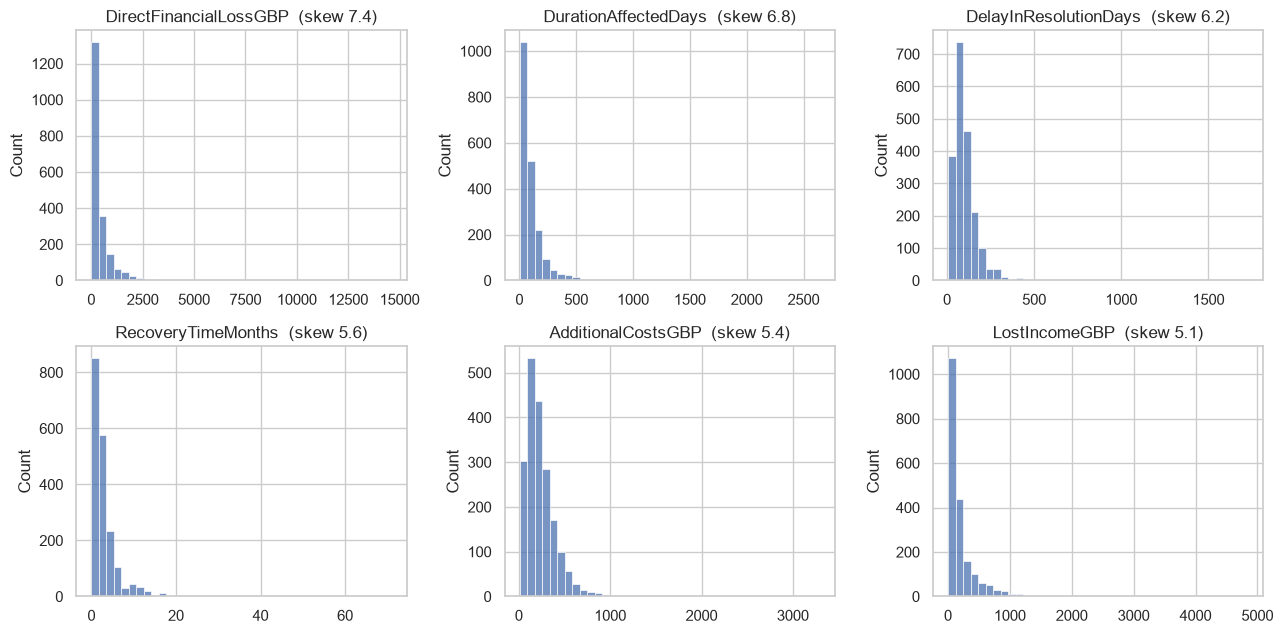

In [8]:
heavy = desc.sort_values("skew", ascending=False).index[:6]
fig, axes = plt.subplots(2, 3, figsize=(13, 6.5))
for ax, col in zip(axes.ravel(), heavy):
    sns.histplot(train[col].dropna(), bins=40, ax=ax, color="#4c72b0")
    ax.set_title(f"{col}  (skew {desc.loc[col, 'skew']:.1f})"); ax.set_xlabel("")
plt.tight_layout(); plt.show()

Skew is high on money and duration fields. We add `log1p` copies for linear models and keep the raw columns for trees.


## 6. Outliers after cleaning

After removing bad ranges, check whether the remaining tails need more treatment.


In [9]:
rows = []
for col in numeric_cols:
    s = train[col].dropna()
    q1, q3 = s.quantile([0.25, 0.75]); iqr = q3 - q1
    rows.append({
        "column": col,
        "iqr_outliers": int(((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).sum()),
        "z>3": int((np.abs(stats.zscore(s)) > 3).sum()),
        "max/p99": round(s.max() / max(s.quantile(0.99), 1e-9), 2),
    })
display(pd.DataFrame(rows).sort_values("iqr_outliers", ascending=False).reset_index(drop=True))

,column,iqr_outliers,z>3,max/p99
0,LostIncomeGBP,208,39,2.71
1,ExpectedFinancialRedressGBP,189,47,2.29
2,DirectFinancialLossGBP,186,30,4.28
3,PriorComplaintsRaised,181,13,2.00
4,RecoveryTimeMonths,146,29,3.23
5,DurationAffectedDays,133,31,5.14
6,RepeatFailuresCount,111,32,1.50
7,DelayInResolutionDays,98,28,4.73
8,AdditionalCostsGBP,78,24,3.20
9,NumberOfOrganisationsInvolved,75,12,1.25


Tails look real (large awards, long delays). No extra trimming. Logs help linear models; trees can use the raw values.


## 7. Categorical fields

Decide encoding: one-hot for nominal, integer codes for ordered fields, 0/1 for Yes/No.


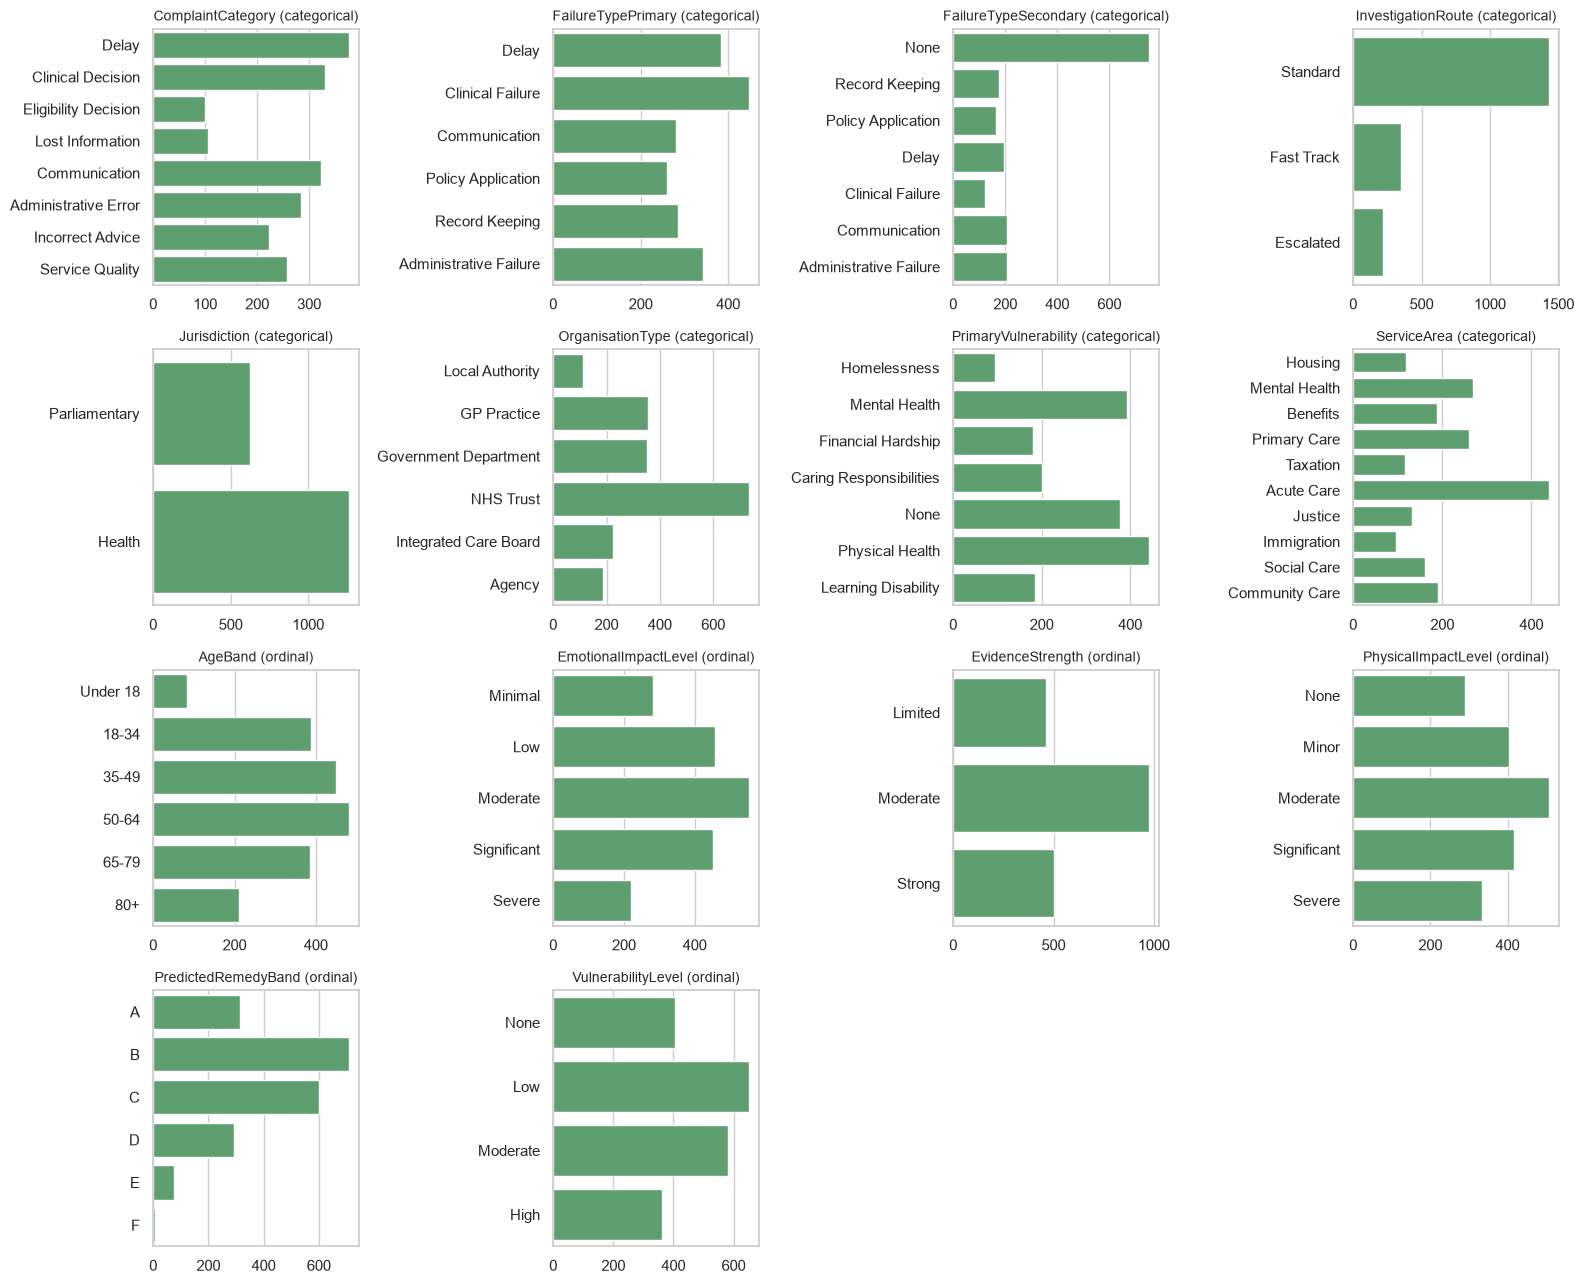

,AnxietyReported,DeteriorationInHealth,AdditionalTreatmentRequired,SleepDisruptionReported,MultipleComplaintThemes,DepressionReported,ImpactOnRelationships,RepeatedFailurePattern,EscalatedInternally,SafeguardingConcern,LegalChallengePotential,LongTermImpactFlag,BereavedPerson
share_yes,0.492,0.468,0.406,0.383,0.355,0.274,0.267,0.25,0.164,0.116,0.114,0.053,0.03


In [10]:
cat_cols = [c for c in contracts.categorical_columns() + contracts.ordinal_columns() if c in train]
fig, axes = plt.subplots(4, 4, figsize=(16, 13))
for ax, col in zip(axes.ravel(), cat_cols):
    order = contracts.get(col).allowed_values if contracts.get(col).kind is contracts.ColumnKind.ORDINAL else None
    sns.countplot(y=train[col], order=order, ax=ax, color="#55a868")
    ax.set_title(f"{col} ({contracts.get(col).kind.value})", fontsize=10); ax.set_ylabel(""); ax.set_xlabel("")
for ax in axes.ravel()[len(cat_cols):]:
    ax.axis("off")
plt.tight_layout(); plt.show()

bool_cols = [c for c in contracts.boolean_columns() if c in train]
display((train[bool_cols] == "Yes").mean().sort_values(ascending=False).rename("share_yes").round(3).to_frame().T)

## 8. Signal by severity

See which fields move with severity. Flat fields are weak; smooth shifts are useful.


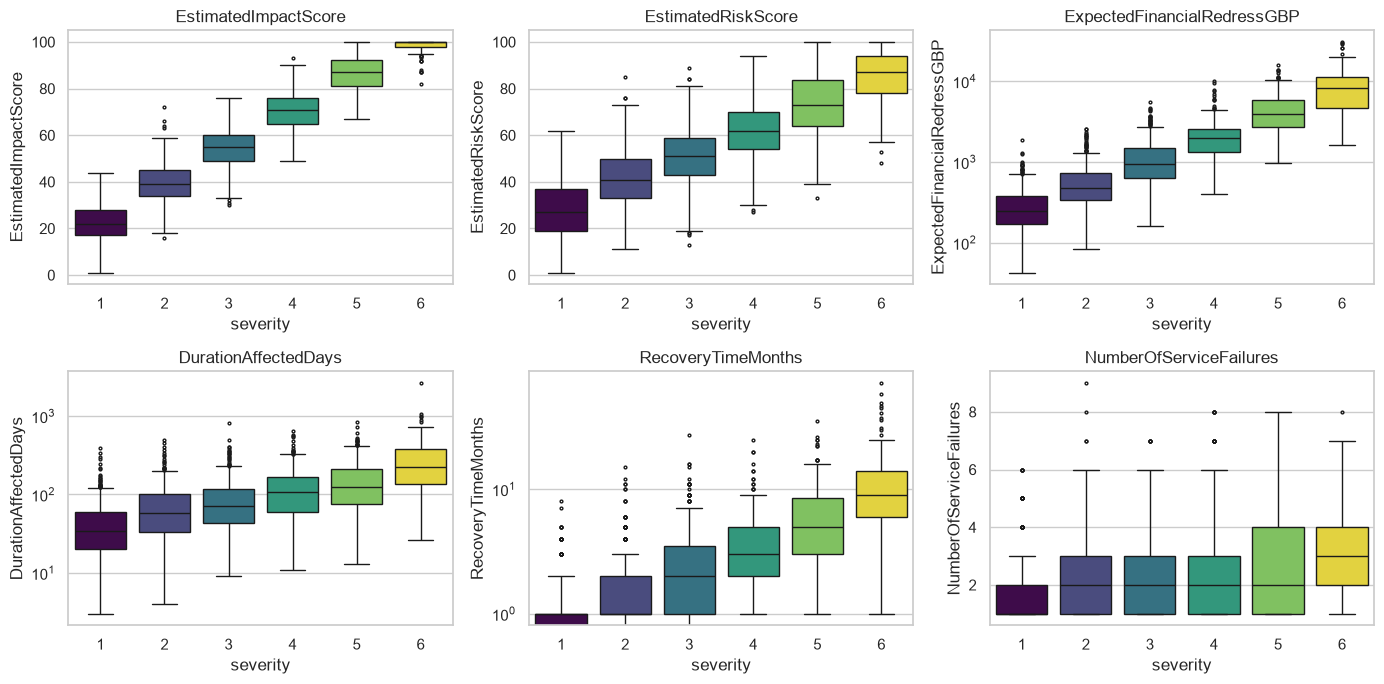

In [11]:
key = ["EstimatedImpactScore", "EstimatedRiskScore", "ExpectedFinancialRedressGBP", "DurationAffectedDays", "RecoveryTimeMonths", "NumberOfServiceFailures"]
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.ravel(), key):
    sns.boxplot(data=train, x=TARGET, y=col, hue=TARGET, palette="viridis", legend=False, ax=ax, fliersize=2)
    if train[col].skew() > 2:
        ax.set_yscale("log")
    ax.set_title(col); ax.set_xlabel("severity")
plt.tight_layout(); plt.show()

EstimatedImpactScore


SeverityScore,1,2,3,4,5,6
min,1.0,16.0,30.0,49.0,67.0,82.0
p5,8.0,26.0,42.0,57.0,73.0,92.0
median,22.0,39.0,55.0,71.0,87.0,100.0
p95,36.1,52.1,67.0,84.4,99.0,100.0
max,44.0,72.0,76.0,93.0,100.0,100.0


EstimatedRiskScore


SeverityScore,1,2,3,4,5,6
min,1.0,11.0,13.0,27.0,33.0,48.0
p5,8.0,21.0,31.0,40.0,53.1,62.0
median,27.0,41.0,51.0,62.0,73.0,87.0
p95,47.0,62.0,73.0,80.2,92.9,100.0
max,62.0,85.0,89.0,94.0,100.0,100.0


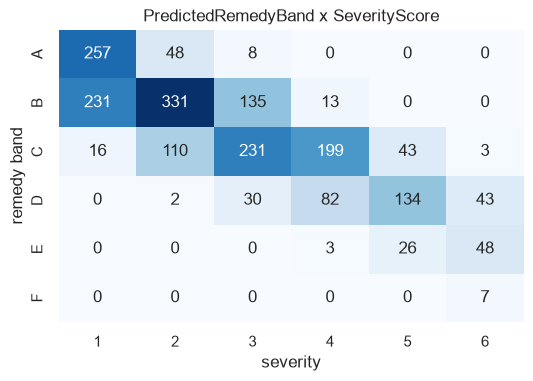

In [12]:
# Overlap between adjacent severity classes for the internal-assessment proxies.
def class_ranges(col):
    g = train.groupby(TARGET)[col]
    return pd.DataFrame({"min": g.min(), "p5": g.quantile(0.05), "median": g.median(), "p95": g.quantile(0.95), "max": g.max()}).round(1)

for col in ["EstimatedImpactScore", "EstimatedRiskScore"]:
    print(col); display(class_ranges(col).T)

ct = pd.crosstab(train["PredictedRemedyBand"], train[TARGET])
fig, ax = plt.subplots(figsize=(6, 3.8))
sns.heatmap(ct, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
ax.set_title("PredictedRemedyBand x SeverityScore"); ax.set_xlabel("severity"); ax.set_ylabel("remedy band")
plt.show()

`EstimatedImpactScore` rises with severity (medians roughly 22, 38, 55, 70, 87, 100), but neighbouring classes still overlap. So it is strong, not a perfect lookup.

`EstimatedRiskScore` and `PredictedRemedyBand` are related. They exist in holdback, so Regime A uses them. Regime B drops them to measure dependence.


## 9. Leakage check

Look for columns that copy the target. Those inflate scores and fail on holdback.


In [13]:
progressed = train_raw[TARGET] >= settings.data.progress_threshold
leak = pd.crosstab(train_raw["OmbudsmanInvestigationRequired"], progressed.rename("progressed"))
display(leak)
print("Off-diagonal cases:", int(leak.values[0, 1] + leak.values[1, 0]), "-> a perfect restatement of the decision.")

print("\nNegative control - InvestigationRoute vs severity (row %):")
display(pd.crosstab(train_raw["InvestigationRoute"], train_raw[TARGET], normalize="index").round(3))

progressed,False,True
OmbudsmanInvestigationRequired,,
No,1399,0
Yes,0,601


Off-diagonal cases: 0 -> a perfect restatement of the decision.

Negative control - InvestigationRoute vs severity (row %):


SeverityScore,1,2,3,4,5,6
InvestigationRoute,,,,,,
Escalated,0.271,0.275,0.174,0.147,0.106,0.028
Fast Track,0.259,0.224,0.178,0.167,0.112,0.060
Standard,0.248,0.246,0.212,0.144,0.098,0.052


`OmbudsmanInvestigationRequired` is Yes for every severity 4-6 and No for every 1-3. It is also missing for all holdback rows. Dropped in cleaning; a test fails if it comes back as a feature.

`InvestigationRoute` barely changes with severity, so it is a useful negative control.


## 10. Correlation

Check redundancy between numeric features (Spearman + VIF).


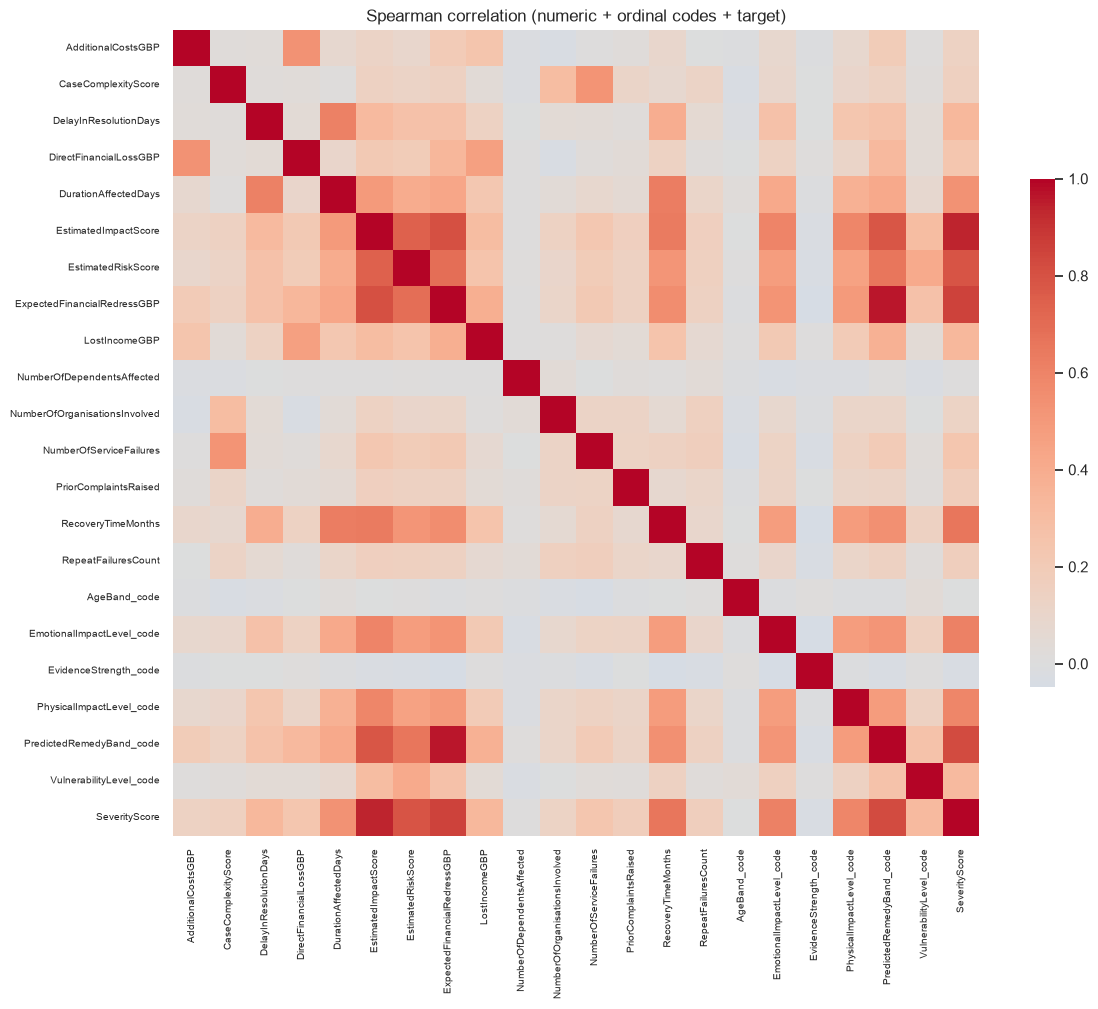

,EstimatedImpactScore,ExpectedFinancialRedressGBP,PredictedRemedyBand_code,EstimatedRiskScore,RecoveryTimeMonths,EmotionalImpactLevel_code,PhysicalImpactLevel_code,DurationAffectedDays,DelayInResolutionDays,LostIncomeGBP,VulnerabilityLevel_code,DirectFinancialLossGBP,NumberOfServiceFailures,PriorComplaintsRaised,RepeatFailuresCount,CaseComplexityScore,AdditionalCostsGBP,NumberOfOrganisationsInvolved,NumberOfDependentsAffected,AgeBand_code,EvidenceStrength_code
spearman_with_target,0.941,0.855,0.828,0.793,0.66,0.609,0.592,0.532,0.335,0.331,0.316,0.242,0.238,0.177,0.169,0.154,0.133,0.131,0.003,-0.002,-0.034


In [14]:
X_raw, y = split_features_target(train, settings)
X_eng, spec = engineer_features(X_raw, settings)

corr_cols = numeric_cols + [c for c in X_eng.columns if c.endswith("_code")]
corr = pd.concat([X_eng[corr_cols], y.rename(TARGET)], axis=1).corr(method="spearman")
fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True, cbar_kws={"shrink": 0.6}, ax=ax, xticklabels=True, yticklabels=True)
ax.set_title("Spearman correlation (numeric + ordinal codes + target)")
plt.xticks(fontsize=7); plt.yticks(fontsize=7); plt.show()

display(corr[TARGET].drop(TARGET).sort_values(ascending=False).round(3).to_frame("spearman_with_target").T)

In [15]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_frame = X_eng[numeric_cols].fillna(X_eng[numeric_cols].median())
vif_frame = vif_frame.loc[:, vif_frame.std() > 0]
vif = pd.Series(
    [variance_inflation_factor(vif_frame.to_numpy(), i) for i in range(vif_frame.shape[1])],
    index=vif_frame.columns, name="VIF"
).sort_values(ascending=False)
display(vif.round(2).to_frame().T)
print("Columns with VIF > 5:", list(vif[vif > 5].index))

,DurationAffectedDays,EstimatedImpactScore,DirectFinancialLossGBP,DelayInResolutionDays,AdditionalCostsGBP,EstimatedRiskScore,RecoveryTimeMonths,ExpectedFinancialRedressGBP,CaseComplexityScore,NumberOfServiceFailures,LostIncomeGBP,NumberOfOrganisationsInvolved,RepeatFailuresCount,PriorComplaintsRaised,NumberOfDependentsAffected
VIF,3.38,2.98,2.76,2.74,2.52,2.37,1.95,1.84,1.64,1.58,1.25,1.16,1.09,1.06,1.01


Columns with VIF > 5: []


Main link is `EstimatedImpactScore` with `EstimatedRiskScore`. Nothing extreme on VIF. Trees are fine; linear models use L2.


## 11. Categorical vs target

Cramer's V for nominal fields vs severity.


In [16]:
def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2, p, _, _ = stats.chi2_contingency(ct)
    n = ct.values.sum(); r, k = ct.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1))), p

rows = []
for col in contracts.categorical_columns() + contracts.ordinal_columns() + contracts.boolean_columns():
    if col in train:
        v, p = cramers_v(train[col].fillna("(missing)"), train[TARGET])
        rows.append({"column": col, "kind": contracts.get(col).kind.value, "cramers_v": round(v, 3), "p_value": p})
assoc = pd.DataFrame(rows).sort_values("cramers_v", ascending=False).reset_index(drop=True)
display(assoc)

,column,kind,cramers_v,p_value
0,PredictedRemedyBand,ordinal,0.514,0.000000e+00
1,LongTermImpactFlag,boolean,0.453,1.235119e-86
2,EmotionalImpactLevel,ordinal,0.310,1.291404e-186
3,AdditionalTreatmentRequired,boolean,0.308,4.316874e-39
4,PhysicalImpactLevel,ordinal,0.298,1.868339e-171
5,DeteriorationInHealth,boolean,0.285,3.833027e-33
6,RepeatedFailurePattern,boolean,0.271,7.662433e-30
7,AnxietyReported,boolean,0.236,2.443520e-22
8,SleepDisruptionReported,boolean,0.235,3.845596e-22
9,DepressionReported,boolean,0.223,6.516543e-20


## 12. Mutual information

Quick ranking of engineered features before modelling. Sanity check only.


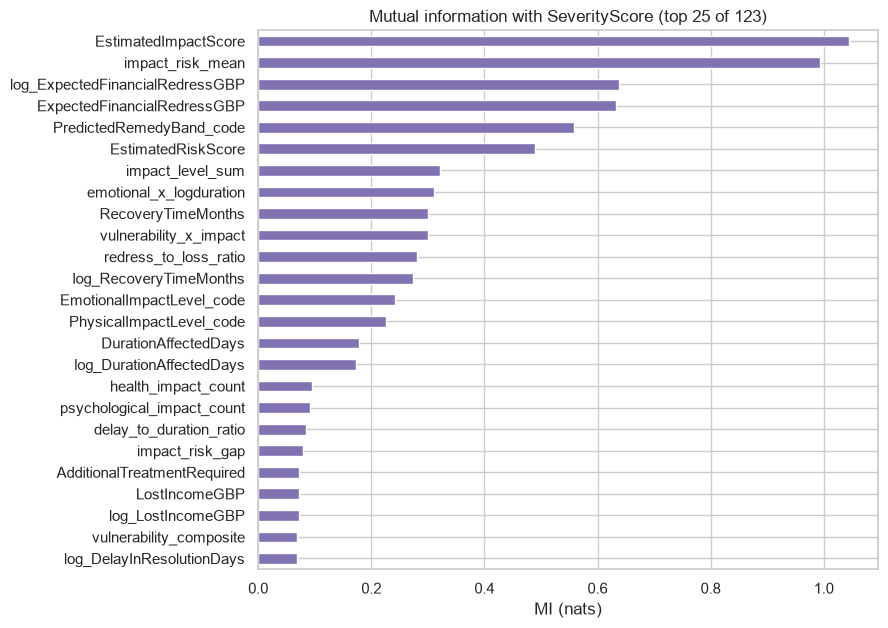

Features with MI < 0.005: 48 of 123


In [17]:
from sklearn.feature_selection import mutual_info_classif
from severity_triage.features import build_preprocessor

Xt = build_preprocessor(spec, scale=False).fit_transform(X_eng)
mi = pd.Series(mutual_info_classif(Xt, y, random_state=settings.project.seed), index=Xt.columns).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 7))
mi.head(25).iloc[::-1].plot.barh(ax=ax, color="#8172b2")
ax.set_title("Mutual information with SeverityScore (top 25 of %d)" % len(mi)); ax.set_xlabel("MI (nats)")
plt.show()
print("Features with MI < 0.005:", int((mi < 0.005).sum()), "of", len(mi))

## 13. Subgroup base rates

Check if severe cases cluster in particular groups.


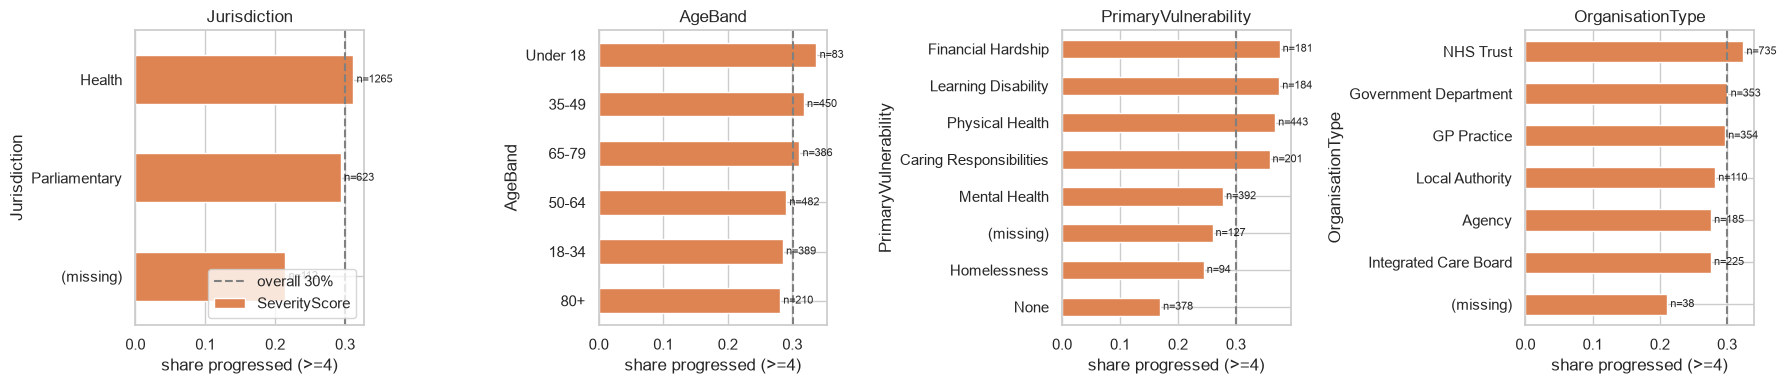

In [18]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, settings.robustness.subgroup_columns):
    rate = train.groupby(train[col].fillna("(missing)"))[TARGET].apply(lambda s: (s >= 4).mean()).sort_values()
    n = train[col].fillna("(missing)").value_counts()
    rate.plot.barh(ax=ax, color="#dd8452")
    ax.axvline((y >= 4).mean(), color="grey", linestyle="--", label="overall 30%")
    ax.set_title(col); ax.set_xlabel("share progressed (>=4)")
    for i, (lvl, r) in enumerate(rate.items()):
        ax.text(r + 0.005, i, f"n={n[lvl]}", va="center", fontsize=8)
axes[0].legend(loc="lower right")
plt.tight_layout(); plt.show()

Severe rates are near the overall 30% in the subgroups checked. Evaluation still reports recall by group later.


## 14. Train vs holdback

Check whether holdback looks like training (same period, same mix).


In [19]:
hold = cleaned_hold.frame
rows = []
for col in numeric_cols:
    a, b = train[col].dropna(), hold[col].dropna()
    ks, p = stats.ks_2samp(a, b)
    rows.append({"column": col, "test": "KS", "statistic": round(ks, 3), "p_value": round(p, 3)})
for col in contracts.categorical_columns() + contracts.ordinal_columns():
    ct = pd.concat([train[col].value_counts().rename("train"), hold[col].value_counts().rename("hold")], axis=1).fillna(0)
    chi2, p, _, _ = stats.chi2_contingency(ct.T.values)
    rows.append({"column": col, "test": "chi2", "statistic": round(chi2, 2), "p_value": round(p, 3)})
shift = pd.DataFrame(rows).sort_values("p_value")
display(shift.head(12))
print("Columns with p < 0.05:", int((shift["p_value"] < 0.05).sum()), "of", len(shift), "(about 5% expected by chance)")
print("Training dates:", train["CaseCreatedDate"].min().date(), "to", train["CaseCreatedDate"].max().date())
print("Holdback dates:", hold["CaseCreatedDate"].min().date(), "to", hold["CaseCreatedDate"].max().date())

,column,test,statistic,p_value
18,InvestigationRoute,chi2,6.510,0.039
24,EmotionalImpactLevel,chi2,9.720,0.045
26,PhysicalImpactLevel,chi2,9.600,0.048
23,AgeBand,chi2,9.090,0.106
16,FailureTypePrimary,chi2,8.620,0.125
15,ComplaintCategory,chi2,11.000,0.139
28,VulnerabilityLevel,chi2,4.060,0.255
21,PrimaryVulnerability,chi2,7.350,0.290
19,Jurisdiction,chi2,1.040,0.308
17,FailureTypeSecondary,chi2,7.060,0.316


Columns with p < 0.05: 3 of 29 (about 5% expected by chance)
Training dates: 2023-01-01 to 2026-06-30
Holdback dates: 2023-01-01 to 2026-06-28


Holdback looks like a random draw from the same window as training. Stratified CV is enough; no need for a time split.


## 15. Decisions taken into the pipeline

| Finding | Decision |
|---|---|
| Two undocumented Yes/No columns | Keep; note in README |
| `OmbudsmanInvestigationRequired` | Drop; guarded by test |
| Out-of-range numerics | Set to missing |
| Light missingness | Impute inside CV; add indicators |
| Skewed money/duration | Add log features |
| Strong internal scores | Use in Regime A; compare Regime B |
| No train/holdback shift | Stratified CV |

Next: notebook 02 for models and the triage decision.
